# Vegetation Recommendation Modeling Notebook

Notebook ini menyiapkan dataset final, melakukan EDA, membandingkan beberapa model tabular, melakukan tuning secukupnya, lalu menyimpan artifact model untuk sistem rekomendasi vegetasi/tanaman berbasis kondisi tanah dan lingkungan.

Notebook ini juga disiapkan agar kompatibel dengan Google Colab. Jika dijalankan di Colab, simpan seluruh project folder ke `/content/DATAHACTHON` atau mount Google Drive lalu arahkan `COLAB_PROJECT_ROOT` ke folder project Anda.


## Colab Setup

Jika notebook ini dibuka di Google Colab:

1. Pastikan seluruh isi project tersedia, bukan hanya file notebook.
2. Opsi termudah adalah meletakkan project di `/content/DATAHACTHON`.
3. Jika project ada di Google Drive, ubah `MOUNT_GOOGLE_DRIVE = True` dan isi `COLAB_PROJECT_ROOT`.
4. Jalankan cell setup berikut sebelum cell lainnya.


In [1]:
import os
import subprocess
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
MOUNT_GOOGLE_DRIVE = False
COLAB_PROJECT_ROOT = None
# Contoh:
# COLAB_PROJECT_ROOT = "/content/drive/MyDrive/DATAHACTHON"

if IN_COLAB and MOUNT_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")

if IN_COLAB:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "pandas",
            "scikit-learn",
            "matplotlib",
            "seaborn",
            "joblib",
            "nbformat",
        ]
    )


def _is_project_root(path: Path) -> bool:
    return (path / "scripts").exists() and (path / "datasets").exists()


def resolve_project_root(explicit_root: str | None = None) -> Path:
    if explicit_root:
        candidate = Path(explicit_root).expanduser().resolve()
        if _is_project_root(candidate):
            return candidate
        raise FileNotFoundError(
            f"COLAB_PROJECT_ROOT tidak valid: {candidate}. "
            "Folder harus mengandung `scripts/` dan `datasets/`."
        )

    cwd = Path.cwd().resolve()
    direct_candidates = [
        cwd,
        *cwd.parents,
        Path("/content/DATAHACTHON"),
        Path("/content/drive/MyDrive/DATAHACTHON"),
        Path("/content/drive/MyDrive/Colab Notebooks/DATAHACTHON"),
    ]

    seen = set()
    for candidate in direct_candidates:
        candidate_str = str(candidate)
        if candidate_str in seen:
            continue
        seen.add(candidate_str)
        if candidate.exists() and _is_project_root(candidate):
            return candidate

    search_bases = [Path("/content"), Path("/content/drive/MyDrive")]
    search_patterns = [
        "*/scripts/common.py",
        "*/*/scripts/common.py",
        "*/*/*/scripts/common.py",
    ]
    for base in search_bases:
        if not base.exists():
            continue
        for pattern in search_patterns:
            for match in base.glob(pattern):
                candidate = match.parents[1]
                if _is_project_root(candidate):
                    return candidate

    raise FileNotFoundError(
        "Project root tidak ditemukan. "
        "Jika di Colab, upload seluruh folder project ke /content/DATAHACTHON "
        "atau set COLAB_PROJECT_ROOT ke folder project yang benar."
    )


PROJECT_ROOT = resolve_project_root(COLAB_PROJECT_ROOT)
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("IN_COLAB =", IN_COLAB)
print("PROJECT_ROOT =", PROJECT_ROOT)


IN_COLAB = False
PROJECT_ROOT = /home/stardust/Documents/Kuliah/DATAHACTHON


## 1. Project Overview

**Goal**

Membangun baseline realistis untuk memetakan kondisi tanah dan lingkungan ke rekomendasi tanaman.

**Problem formulation**

Baseline diframing sebagai *multiclass classification*, bukan recommender system tradisional, karena dataset yang tersedia memiliki satu label tanaman per observasi dan tidak memiliki user-item interaction atau graded relevance.

**Dataset summary**

Final training dataset dipilih dari sumber berlabel paling kuat dan tidak dipaksa merge dengan sumber lain yang tidak punya kunci join yang andal.


In [2]:
import json

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("deep")

from scripts.data_preparation import prepare_datasets
from scripts.train_model import create_data_splits, infer_feature_types, run_training
from scripts.inference import predict_from_payload
from scripts.common import FINAL_DATASET_PATH, FINAL_METADATA_PATH, MODEL_METRICS_PATH

RANDOM_STATE = 42


## 2. Prepare And Load Dataset

Cell ini menjalankan pipeline preparation agar file processed dan artifact audit selalu sinkron dengan notebook.


In [3]:
prep_summary = prepare_datasets()
dataset = pd.read_csv(FINAL_DATASET_PATH)
metadata = json.loads(FINAL_METADATA_PATH.read_text(encoding="utf-8"))

print(prep_summary)
print("Dataset shape:", dataset.shape)
display(dataset.head())


{'audit_summary_path': 'artifacts/dataset_audit_summary.csv', 'schema_report_path': 'artifacts/dataset_schema_report.md', 'final_dataset_path': 'data/processed/final_dataset.csv', 'final_dataset_minimal_path': 'data/processed/final_dataset_minimal.csv', 'final_dataset_extended_path': 'data/processed/final_dataset_extended.csv', 'metadata_path': 'data/processed/final_dataset_metadata.json', 'rows': 3841, 'target_distribution': {'Teff': 1260, 'Maize': 732, 'Wheat': 715, 'Barley': 503, 'Bean': 253, 'Pea': 94, 'Sorghum': 72, 'Dagussa': 71, 'Niger Seed': 64, 'Potato': 48, 'Red Pepper': 29}}
Dataset shape: (3841, 18)


,record_id,source_dataset,soil_color,ph,nitrogen,phosphorus,potassium,zinc,sulfur,specific_humidity_mean,temperature_mean,temperature_seasonal_range,rainfall_mean,rainfall_total_proxy,soil_moisture_surface,cloud_amount,surface_pressure,target_crop
0,rec_00001,mendeley_8v757rr4st,yellowish_brown,5.81,0.23,5.401,738.231,2.976000,13.816,10.024167,16.512917,23.136667,6.229167,24.916667,0.73,56.57,77.03,Barley
1,rec_00002,mendeley_8v757rr4st,yellowish_brown,5.43,0.23,10.478,606.382,3.077000,16.421,10.024167,16.512917,23.136667,6.229167,24.916667,0.73,56.57,77.03,Barley
2,rec_00003,mendeley_8v757rr4st,brown,5.41,0.23,6.847,386.580,6.611000,16.557,10.024167,16.512917,23.136667,6.229167,24.916667,0.73,56.57,77.03,Barley
3,rec_00004,mendeley_8v757rr4st,red,5.65,0.23,3.418,207.086,0.460181,16.075,10.024167,16.512917,23.136667,6.229167,24.916667,0.73,56.57,77.03,Barley
4,rec_00005,mendeley_8v757rr4st,red,5.27,0.23,39.282,317.357,2.743000,12.558,10.024167,16.512917,23.136667,6.229167,24.916667,0.73,56.57,77.03,Barley


In [4]:
print("Columns:")
print(dataset.columns.tolist())
print("\nClass distribution:")
display(dataset["target_crop"].value_counts().rename_axis("target_crop").reset_index(name="count"))
print("\nMissing values:")
display(
    dataset.isna()
    .sum()
    .sort_values(ascending=False)
    .rename_axis("column")
    .reset_index(name="missing_count")
)


Columns:
['record_id', 'source_dataset', 'soil_color', 'ph', 'nitrogen', 'phosphorus', 'potassium', 'zinc', 'sulfur', 'specific_humidity_mean', 'temperature_mean', 'temperature_seasonal_range', 'rainfall_mean', 'rainfall_total_proxy', 'soil_moisture_surface', 'cloud_amount', 'surface_pressure', 'target_crop']

Class distribution:


,target_crop,count
0,Teff,1260
1,Maize,732
2,Wheat,715
3,Barley,503
4,Bean,253
5,Pea,94
6,Sorghum,72
7,Dagussa,71
8,Niger Seed,64
9,Potato,48



Missing values:


,column,missing_count
0,record_id,0
1,source_dataset,0
2,soil_color,0
3,ph,0
4,nitrogen,0
5,phosphorus,0
6,potassium,0
7,zinc,0
8,sulfur,0
9,specific_humidity_mean,0


## 3. Exploratory Data Analysis

Fokus EDA adalah memeriksa distribusi target, ketersediaan data, hubungan antar fitur numerik, dan kualitas sinyal fitur inti.


Class imbalance ratio (max/min): 43.45
Key insight: missing values are negligible, but class imbalance is material enough to justify macro metrics and class-balanced models.


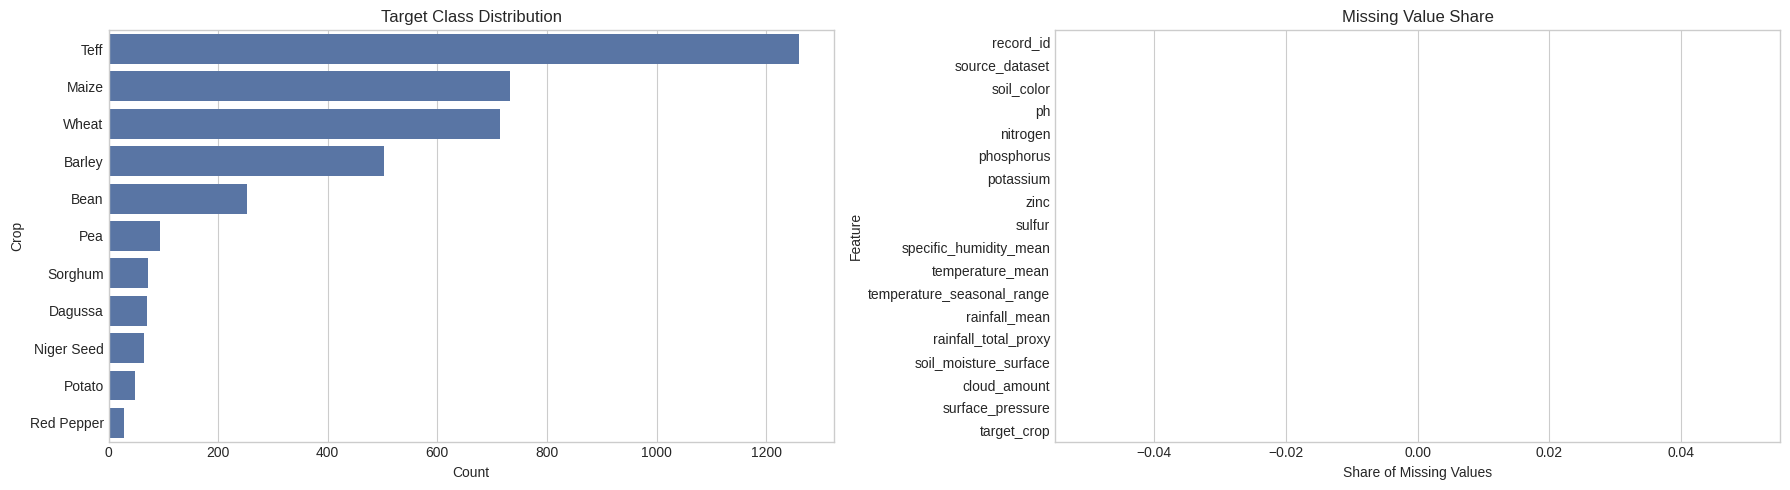

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
target_counts = dataset["target_crop"].value_counts()
sns.barplot(x=target_counts.values, y=target_counts.index, ax=axes[0])
axes[0].set_title("Target Class Distribution")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Crop")

missing_share = dataset.isna().mean().sort_values(ascending=False)
sns.barplot(x=missing_share.values, y=missing_share.index, ax=axes[1])
axes[1].set_title("Missing Value Share")
axes[1].set_xlabel("Share of Missing Values")
axes[1].set_ylabel("Feature")
plt.tight_layout()

imbalance_ratio = target_counts.max() / target_counts.min()
print(f"Class imbalance ratio (max/min): {imbalance_ratio:.2f}")
print("Key insight: missing values are negligible, but class imbalance is material enough to justify macro metrics and class-balanced models.")


Top absolute correlations:
rainfall_mean           rainfall_total_proxy      1.000000
surface_pressure        temperature_mean          0.934660
specific_humidity_mean  surface_pressure          0.867313
temperature_mean        specific_humidity_mean    0.755589
specific_humidity_mean  rainfall_mean             0.755106
rainfall_mean           soil_moisture_surface     0.698100
cloud_amount            soil_moisture_surface     0.567289
potassium               phosphorus                0.515366
                        zinc                      0.492535
zinc                    phosphorus                0.458300
dtype: float64


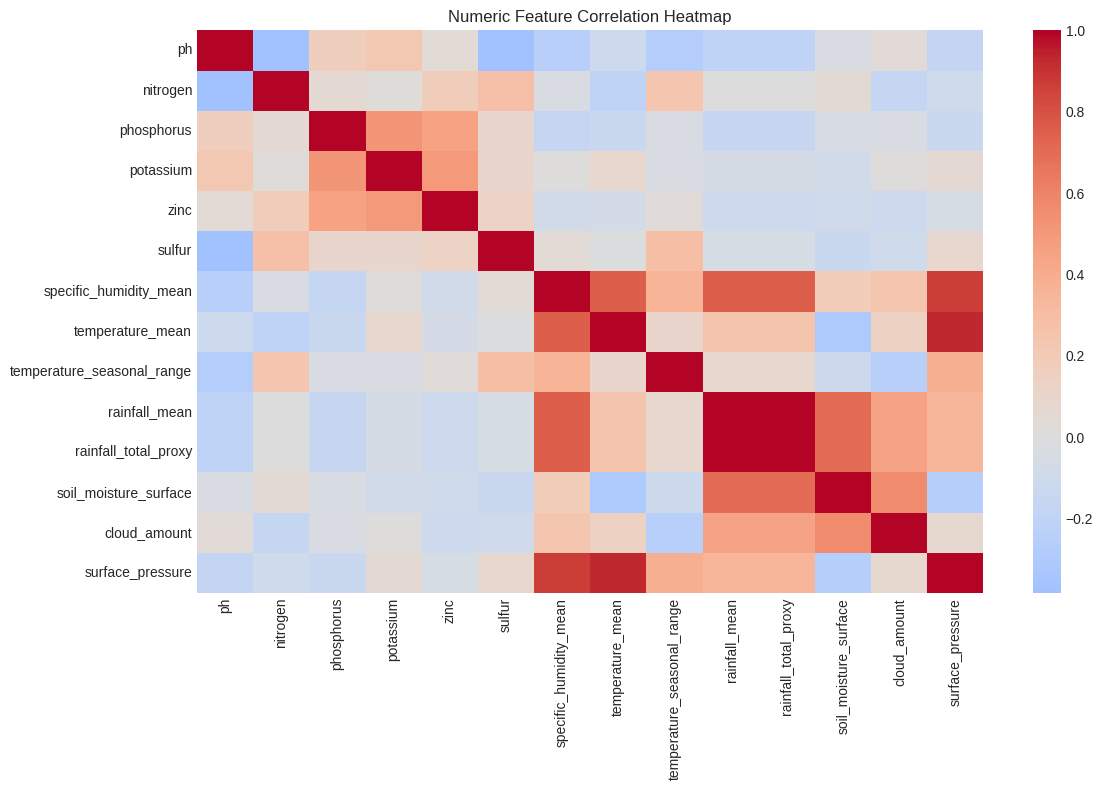

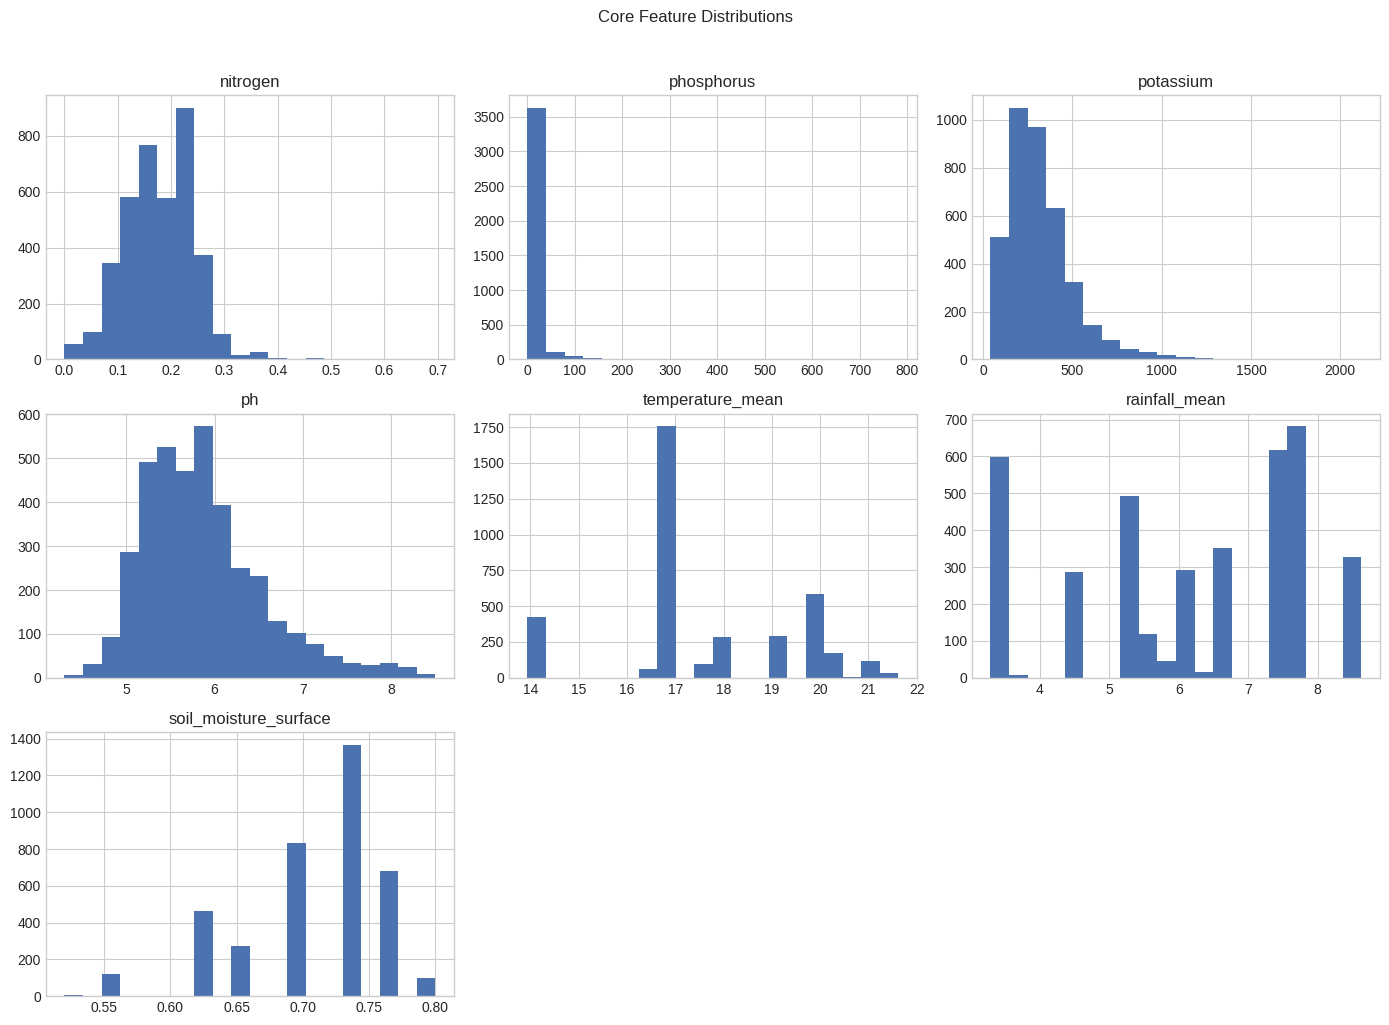

In [6]:
numeric_cols = dataset.select_dtypes(include=["number"]).columns.tolist()
corr = dataset[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Numeric Feature Correlation Heatmap")
plt.tight_layout()

core_features = [
    "nitrogen",
    "phosphorus",
    "potassium",
    "ph",
    "temperature_mean",
    "rainfall_mean",
    "soil_moisture_surface",
]
dataset[core_features].hist(figsize=(14, 10), bins=20)
plt.suptitle("Core Feature Distributions", y=1.02)
plt.tight_layout()

strongest_pairs = (
    corr.where(~np.eye(len(corr), dtype=bool))
    .abs()
    .unstack()
    .sort_values(ascending=False)
    .drop_duplicates()
    .head(10)
)
print("Top absolute correlations:")
print(strongest_pairs)


## 4. Data Preprocessing

Split dilakukan secara stratified. Preprocessing aktual dijalankan di dalam scikit-learn pipeline untuk menghindari data leakage.


In [7]:
splits = create_data_splits(dataset, random_state=RANDOM_STATE)
numeric_features, categorical_features = infer_feature_types(splits["X_train"])

split_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [len(splits["X_train"]), len(splits["X_val"]), len(splits["X_test"])],
    }
)
display(split_summary)
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


,split,rows
0,train,2688
1,validation,576
2,test,577


Numeric features: ['ph', 'nitrogen', 'phosphorus', 'potassium', 'zinc', 'sulfur', 'specific_humidity_mean', 'temperature_mean', 'temperature_seasonal_range', 'rainfall_mean', 'rainfall_total_proxy', 'soil_moisture_surface', 'cloud_amount', 'surface_pressure']
Categorical features: ['soil_color']


## 5. Baseline Models And Comparison

Notebook menggunakan fungsi reusable dari `scripts/train_model.py` agar hasil notebook dan artifact CLI tetap identik.


In [8]:
results = run_training(save_artifacts=True, random_state=RANDOM_STATE)
comparison_df = results["comparison_df"]
display(comparison_df)
print("Best model from CV:", results["metrics_payload"]["best_model_name"])
print("Best CV macro F1:", round(results["metrics_payload"]["best_cv_macro_f1"], 4))


,model_name,cv_accuracy_mean,cv_precision_macro_mean,cv_recall_macro_mean,cv_f1_macro_mean,cv_accuracy_std,cv_f1_macro_std
0,random_forest,0.490699,0.324679,0.301622,0.305390,0.016550,0.005803
1,extra_trees,0.382812,0.270625,0.370980,0.269776,0.012860,0.017671
2,logistic_regression,0.241815,0.251638,0.378256,0.208649,0.022629,0.016564


Best model from CV: random_forest
Best CV macro F1: 0.3165


## 6. Hyperparameter Tuning And Final Evaluation

Hanya model terbaik dari CV yang ditune. Evaluasi akhir dilakukan pada hold-out test set setelah model ditrain ulang pada gabungan train + validation.


In [9]:
metrics_payload = results["metrics_payload"]
print("Best params:")
print(metrics_payload["best_model_params"])

validation_metrics = pd.DataFrame([metrics_payload["validation_metrics"]], index=["validation"])
test_metrics = pd.DataFrame([metrics_payload["test_metrics"]], index=["test"])
display(pd.concat([validation_metrics, test_metrics]))


Best params:
{'model__n_estimators': 500, 'model__min_samples_leaf': 4, 'model__max_features': 0.6, 'model__max_depth': None}


,accuracy,precision_macro,recall_macro,f1_macro
validation,0.444444,0.285571,0.288863,0.279397
test,0.457539,0.273380,0.308454,0.281464


,precision,recall,f1-score,support
Barley,0.394737,0.394737,0.394737,76.000000
Bean,0.291667,0.184211,0.225806,38.000000
Dagussa,0.200000,0.363636,0.258065,11.000000
Maize,0.554545,0.554545,0.554545,110.000000
Niger Seed,0.000000,0.000000,0.000000,10.000000
Pea,0.111111,0.142857,0.125000,14.000000
Potato,0.166667,0.285714,0.210526,7.000000
Red Pepper,0.090909,0.250000,0.133333,4.000000
Sorghum,0.214286,0.272727,0.240000,11.000000
Teff,0.578199,0.645503,0.610000,189.000000


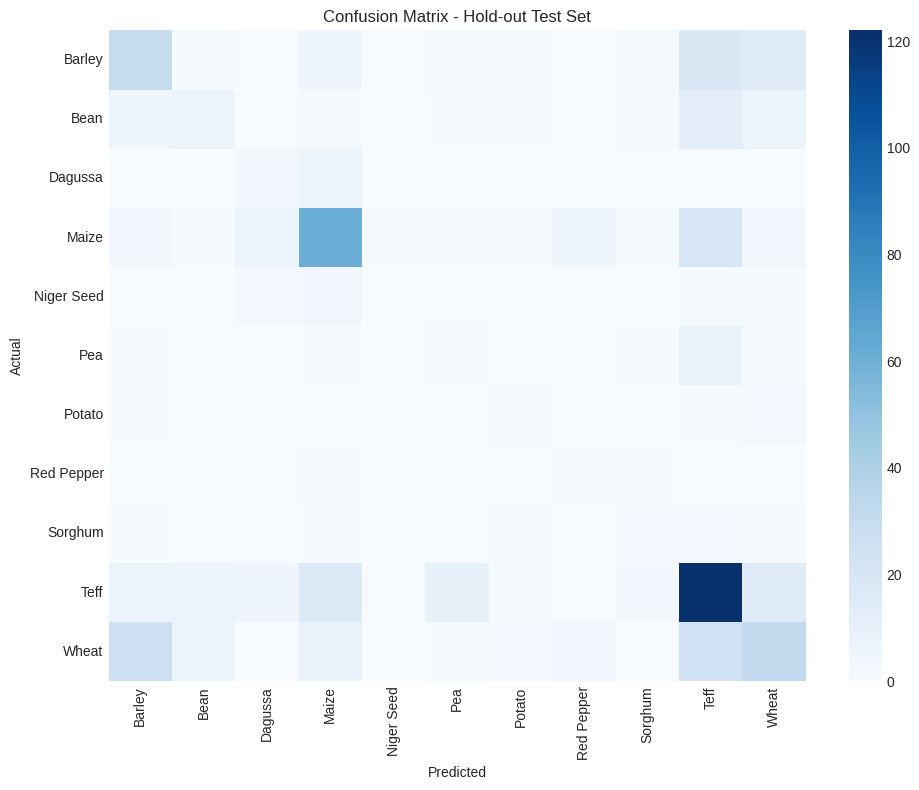

In [10]:
labels = metrics_payload["confusion_matrix_labels"]
cm = pd.DataFrame(metrics_payload["confusion_matrix"], index=labels, columns=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, cmap="Blues", annot=False)
plt.title("Confusion Matrix - Hold-out Test Set")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()

report_df = pd.DataFrame(metrics_payload["classification_report"]).transpose()
display(report_df)


## 7. Feature Importance / Explainability

Permutation importance dipakai agar interpretasi tetap konsisten pada model pipeline penuh dan fitur kategori hasil encoding.


,feature,importance_mean,importance_std
1,ph,0.037023,0.015148
2,nitrogen,0.025442,0.010972
3,phosphorus,0.023865,0.007813
7,specific_humidity_mean,0.021411,0.010316
4,potassium,0.019647,0.010184
6,sulfur,0.019266,0.010897
12,soil_moisture_surface,0.006470,0.004909
8,temperature_mean,0.005630,0.007189
5,zinc,0.003586,0.012137
14,surface_pressure,0.003266,0.004480


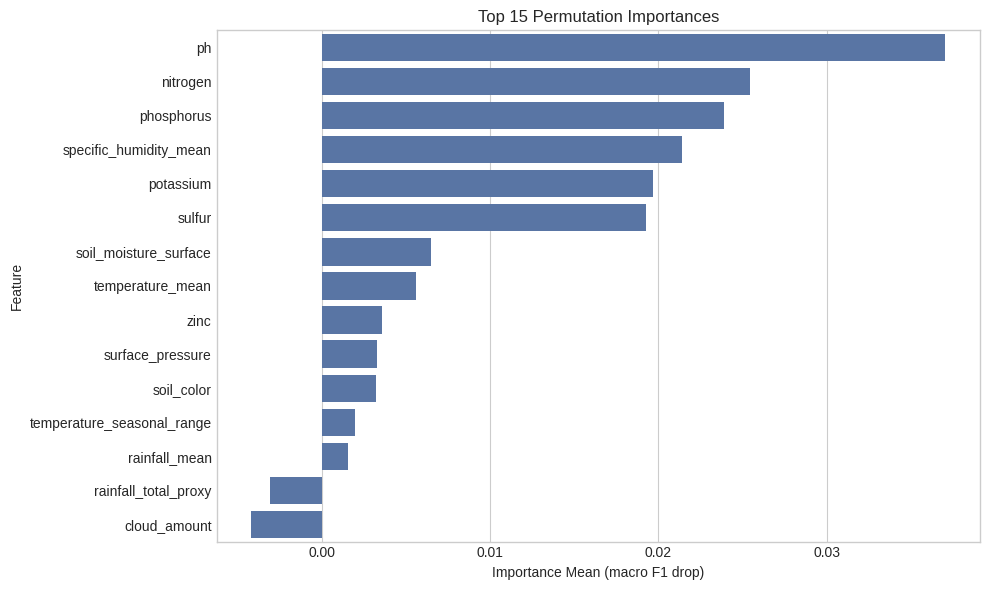

In [11]:
feature_importance_df = results["feature_importance_df"].head(15)
display(feature_importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x="importance_mean", y="feature")
plt.title("Top 15 Permutation Importances")
plt.xlabel("Importance Mean (macro F1 drop)")
plt.ylabel("Feature")
plt.tight_layout()


## 8. Error Analysis

Fokus error analysis adalah melihat kelas yang sulit dibedakan dan contoh misclassifications di test set.


In [12]:
prediction_df = results["prediction_df"]
misclassified = prediction_df.loc[prediction_df["is_correct"] == 0].copy()
print("Misclassified rows:", len(misclassified))
display(misclassified.head(15))

confusion_summary = (
    misclassified.groupby(["actual_target", "predicted_target"]).size().reset_index(name="count")
    .sort_values("count", ascending=False)
)
display(confusion_summary.head(15))


Misclassified rows: 313


,record_id,actual_target,predicted_target,is_correct,top_3_predictions
2,rec_01636,Pea,Teff,0,Teff:0.4720 | Wheat:0.1882 | Barley:0.1086
6,rec_03049,Teff,Maize,0,Maize:0.4415 | Dagussa:0.3126 | Teff:0.1605
9,rec_00922,Maize,Teff,0,Teff:0.2179 | Maize:0.2178 | Barley:0.1752
10,rec_02383,Teff,Maize,0,Maize:0.4855 | Sorghum:0.1461 | Red Pepper:0.1128
11,rec_01562,Niger Seed,Wheat,0,Wheat:0.2486 | Barley:0.2467 | Teff:0.1819
13,rec_03802,Wheat,Barley,0,Barley:0.5260 | Wheat:0.3153 | Bean:0.1551
14,rec_03409,Wheat,Barley,0,Barley:0.3378 | Wheat:0.2392 | Bean:0.1171
16,rec_00866,Maize,Barley,0,Barley:0.2126 | Maize:0.1789 | Wheat:0.1617
18,rec_00331,Barley,Wheat,0,Wheat:0.2827 | Teff:0.1455 | Bean:0.1264
19,rec_01196,Maize,Teff,0,Teff:0.3272 | Maize:0.1990 | Wheat:0.1191


,actual_target,predicted_target,count
52,Wheat,Barley,26
58,Wheat,Teff,25
23,Maize,Teff,20
5,Barley,Teff,18
47,Teff,Maize,17
51,Teff,Wheat,15
6,Barley,Wheat,15
12,Bean,Teff,12
48,Teff,Pea,10
54,Wheat,Maize,9


## 9. Final Recommendation

Model terbaik dipilih berdasarkan macro F1, bukan accuracy saja, untuk mengurangi bias terhadap kelas mayoritas. Jika baseline ini ingin dipindahkan ke konteks Indonesia, langkah berikutnya harus berupa domain adaptation dengan backbone soil/climate Indonesia, bukan sekadar deploy model apa adanya.


In [13]:
print("Best model:", metrics_payload["best_model_name"])
print("Test metrics:", metrics_payload["test_metrics"])
print("Top features:", results["feature_importance_df"].head(10)["feature"].tolist())
print(
    "Recommendation: keep this classifier as the baseline engine, "
    "and use EcoCrop/GAEZ-style rules as a deployment-time plausibility filter."
)


Best model: random_forest
Test metrics: {'accuracy': 0.45753899480069327, 'precision_macro': 0.27338035359653723, 'recall_macro': 0.30845417763317867, 'f1_macro': 0.28146353954734876}
Top features: ['ph', 'nitrogen', 'phosphorus', 'specific_humidity_mean', 'potassium', 'sulfur', 'soil_moisture_surface', 'temperature_mean', 'zinc', 'surface_pressure']
Recommendation: keep this classifier as the baseline engine, and use EcoCrop/GAEZ-style rules as a deployment-time plausibility filter.


## 10. Inference Example

Contoh inferensi sederhana menggunakan median numeric values dan mode categorical value dari dataset final.


In [14]:
example_payload = {}
for column in dataset.columns:
    if column in {"record_id", "source_dataset", "target_crop"}:
        continue
    if pd.api.types.is_numeric_dtype(dataset[column]):
        example_payload[column] = float(dataset[column].median())
    else:
        example_payload[column] = dataset[column].mode().iloc[0]

inference_result = predict_from_payload(example_payload, top_k=3)
inference_result


{'input': {'soil_color': 'brown',
  'ph': 5.78,
  'nitrogen': 0.179519352,
  'phosphorus': 4.0,
  'potassium': 282.0,
  'zinc': 1.5,
  'sulfur': 10.8,
  'specific_humidity_mean': 10.23500000175,
  'temperature_mean': 16.979166667125,
  'temperature_seasonal_range': 23.430000003,
  'rainfall_mean': 6.71833333325,
  'rainfall_total_proxy': 26.873333333,
  'soil_moisture_surface': 0.73,
  'cloud_amount': 59.11,
  'surface_pressure': 78.25},
 'top_predictions': [{'target_crop': 'Teff',
   'probability': 0.29916519840680716},
  {'target_crop': 'Barley', 'probability': 0.17239164610419333},
  {'target_crop': 'Maize', 'probability': 0.1629893203776678}],
 'predicted_target': 'Teff'}

## 11. Saved Artifacts

Semua artifact inti disimpan ke folder `artifacts/` dan bisa dipakai ulang tanpa retraining penuh.


In [15]:
metrics = json.loads(MODEL_METRICS_PATH.read_text(encoding="utf-8"))
print("Artifacts generated:")
for path in [
    "artifacts/model_metrics.json",
    "artifacts/feature_importance.csv",
    "artifacts/prediction_samples.csv",
    "artifacts/models/best_model.joblib",
    "artifacts/pipelines/preprocessing_pipeline.joblib",
    "artifacts/modeling_strategy.md",
]:
    print("-", path)

print("\nTest macro F1:", metrics["test_metrics"]["f1_macro"])


Artifacts generated:
- artifacts/model_metrics.json
- artifacts/feature_importance.csv
- artifacts/prediction_samples.csv
- artifacts/models/best_model.joblib
- artifacts/pipelines/preprocessing_pipeline.joblib
- artifacts/modeling_strategy.md

Test macro F1: 0.28146353954734876
